In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

clean_df = pd.read_pickle(r"D:\DataScience\GUVI\Local\Marketing_campaign_analysis\cleaned_data.pkl")
clean_df


,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp2,Response,Complain,Country,Age,Children,Total_Spend,Total_Purchases,Family_Size,Customer_since
0,342199,Graduation,Together,59011.7,1,0,2012-11-17,3,0,2,...,0,0,0,Spain,41,1,69,13,3,4968
1,8075450,Master,Single,1730.0,1,1,2013-04-10,96,0,0,...,0,0,0,Spain,51,2,39,4,3,4824
2,13664263,Graduation,Married,98584.6,0,0,2014-01-11,99,920,0,...,0,0,0,Australia,48,0,1512,12,2,4548
3,16164787,Graduation,Married,74031.5,1,0,2014-06-18,47,265,0,...,0,0,0,Spain,50,1,478,16,3,4390
4,15815139,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,3,...,0,0,0,Canada,45,2,330,9,3,4419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55995,2485439,Graduation,Married,32533.4,0,0,2013-04-05,99,8,6,...,0,0,0,Australia,41,0,53,19,2,4829
55996,9202496,Basic,Single,70496.3,0,1,2013-01-31,9,835,0,...,0,0,0,Germany,34,1,924,12,2,4893
55997,14677746,Graduation,Together,21072.0,1,0,2013-06-25,24,0,5,...,0,1,0,Saudi Arabia,76,1,608,5,3,4748
55998,3843719,Graduation,Together,64218.1,0,0,2014-05-12,81,8,4,...,0,0,0,Saudi Arabia,50,0,69,8,2,4427


# Univariate analysis

## Age

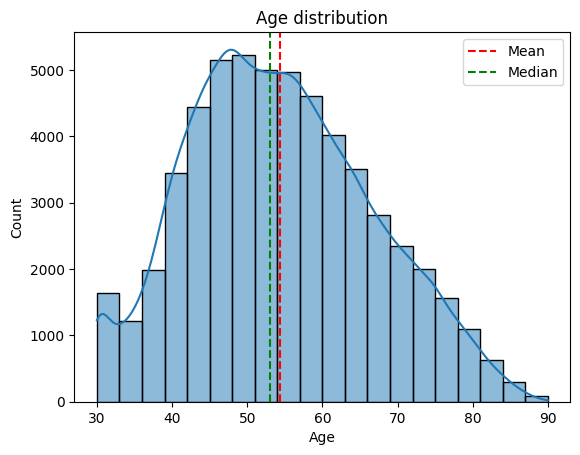

In [ ]:

sns.histplot(clean_df['Age'], bins=20, kde=True)
plt.axvline(clean_df['Age'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['Age'].median(), color='green', linestyle='--', label='Median')
plt.title('Age distribution')
plt.legend()
plt.show()
#since mean>median-right skewed

In [ ]:
print(clean_df['Age'].describe())
#The middle 50% of customers fall between 45 and 63 years of age (IQR), suggesting that the majority of customers belong to the middle-aged demographic

count    55986.000000
mean        54.332851
std         12.210409
min         30.000000
25%         45.000000
50%         53.000000
75%         63.000000
max         90.000000
Name: Age, dtype: float64


In [ ]:
bins = [30, 40, 50, 60, 70, 80,90]
labels = ['30-40', '40-50', '50-60', '60-70', '70-80', '80-90']

clean_df['Age_Group'] = pd.cut(clean_df['Age'], bins=bins, labels=labels)

print(clean_df['Age_Group'].value_counts().sort_index())

# most common age group is 40 to 60

Age_Group
30-40     5983
40-50    16076
50-60    15971
60-70    10534
70-80     5389
80-90     1002
Name: count, dtype: int64


In [ ]:
clean_df['Age'].skew()
#right skewed

np.float64(0.2521686011579412)

## Education

In [12]:
clean_df['Education'].value_counts()

Education
Graduation    22735
PhD           12579
Master        10527
2n Cycle       5964
Basic          4181
Name: count, dtype: int64

In [19]:
print((clean_df['Education'].value_counts(normalize=True)*100).round(2))


Education
Graduation    40.61
PhD           22.47
Master        18.80
2n Cycle      10.65
Basic          7.47
Name: proportion, dtype: float64


In [ ]:
#most common education level
clean_df['Education'].mode()[0]

'Graduation'

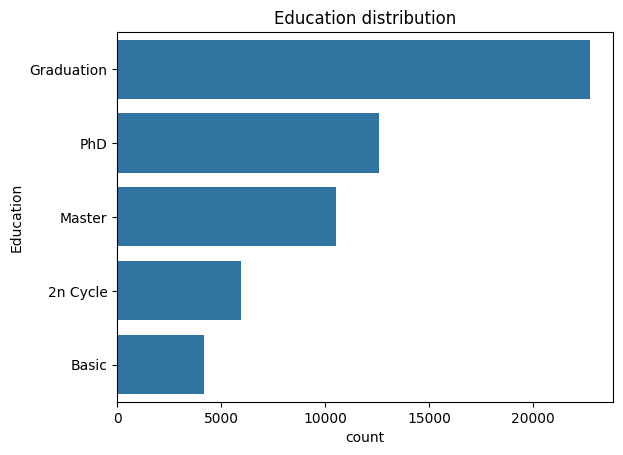

In [28]:
sns.countplot(y='Education', data = clean_df, order=clean_df['Education'].value_counts().index)
plt.title('Education distribution')
plt.show()

## Country

In [21]:
print((clean_df['Country'].value_counts(normalize=True)*100).round(2))

Country
Spain           29.83
Canada          19.19
Saudi Arabia    15.04
Australia       10.13
India            8.60
Germany          7.92
USA              7.73
Mexico           1.56
Name: proportion, dtype: float64


In [22]:
clean_df['Country'].mode()[0]

'Spain'

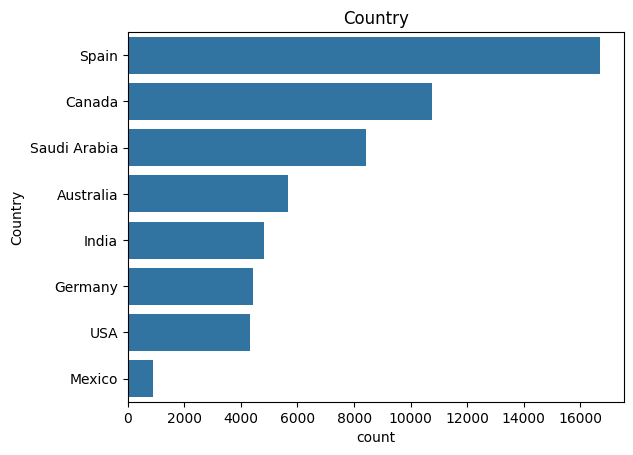

In [29]:
sns.countplot(y='Country', data = clean_df, order=clean_df['Country'].value_counts().index)
plt.title('Country')
plt.show()

## Income

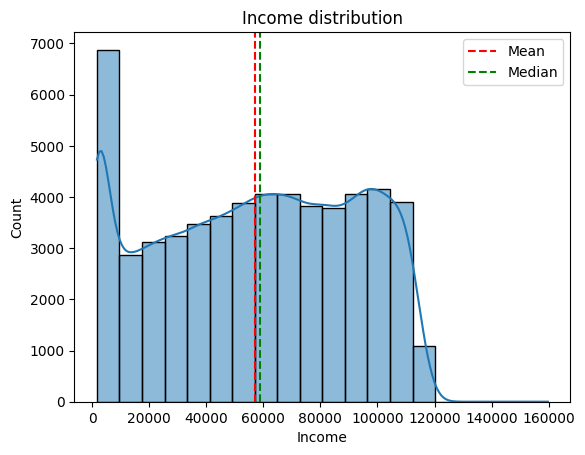

In [17]:
sns.histplot(clean_df['Income'],bins=20, kde=True)
plt.axvline(clean_df['Income'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['Income'].median(), color='green', linestyle='--', label='Median')
plt.title('Income distribution')
plt.legend()
plt.show()


In [18]:
clean_df['Income'].describe()

count     55986.000000
mean      57214.361721
std       34225.632068
min        1730.000000
25%       28240.225000
50%       58828.150000
75%       86917.575000
max      159700.000000
Name: Income, dtype: float64

In [19]:
clean_df['Income'].skew()

np.float64(-0.0931794933129398)

## Spending Analysis

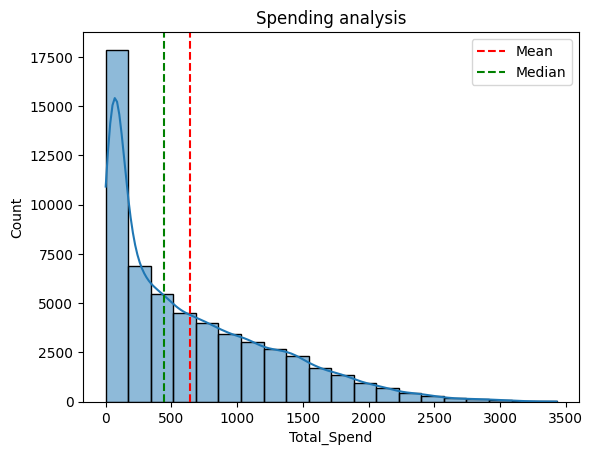

In [21]:
sns.histplot(clean_df['Total_Spend'],bins=20, kde=True)
plt.axvline(clean_df['Total_Spend'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['Total_Spend'].median(), color='green', linestyle='--', label='Median')
plt.title('Spending analysis')
plt.legend()
plt.show()

In [22]:
clean_df['Total_Spend'].describe()

count    55986.000000
mean       640.190583
std        622.599233
min          0.000000
25%        103.000000
50%        441.000000
75%       1020.000000
max       3431.000000
Name: Total_Spend, dtype: float64

In [23]:
clean_df['Total_Spend'].skew()

np.float64(1.0969621766281656)

### Amount on wine

In [55]:
print(f"skewness: {clean_df['MntWines'].skew()}")
clean_df['MntWines'].describe()

skewness: 1.7554162343638582


count    55986.000000
mean       246.957329
std        358.567514
min          0.000000
25%          0.000000
50%         64.000000
75%        353.000000
max       1493.000000
Name: MntWines, dtype: float64

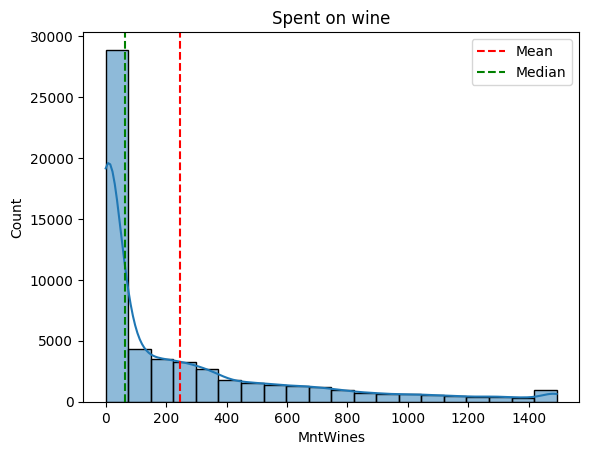

In [56]:
sns.histplot(clean_df['MntWines'],bins=20, kde=True)
plt.axvline(clean_df['MntWines'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['MntWines'].median(), color='green', linestyle='--', label='Median')
plt.title('Spent on wine')
plt.legend()
plt.show()

### Amount on fruits

In [57]:
print(f"skewness: {clean_df['MntFruits'].skew()}")
clean_df['MntFruits'].describe()

skewness: 2.94892534495777


count    55986.000000
mean        16.151842
std         33.932661
min          0.000000
25%          0.000000
50%          0.000000
75%         15.000000
max        199.000000
Name: MntFruits, dtype: float64

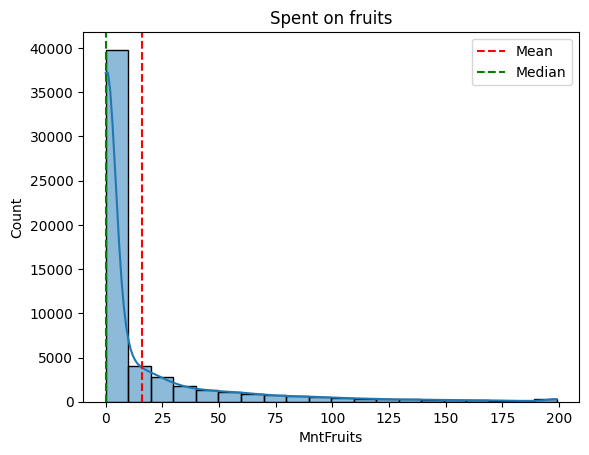

In [58]:
sns.histplot(clean_df['MntFruits'],bins=20, kde=True)
plt.axvline(clean_df['MntFruits'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['MntFruits'].median(), color='green', linestyle='--', label='Median')
plt.title('Spent on fruits')
plt.legend()
plt.show()

### Amount on meat 

In [53]:
print(f"skewness: {clean_df['MntMeatProducts'].skew()}")
clean_df['MntMeatProducts'].describe()

skewness: 1.6007933923300817


count    55986.000000
mean       268.201550
std        342.099196
min          0.000000
25%         42.000000
50%        107.000000
75%        362.000000
max       1341.000000
Name: MntMeatProducts, dtype: float64

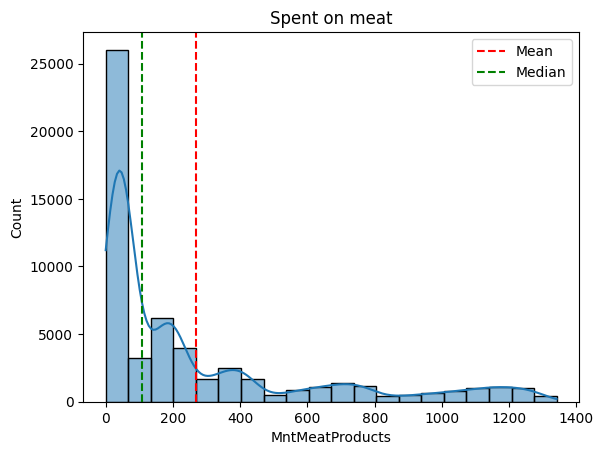

In [54]:
sns.histplot(clean_df['MntMeatProducts'],bins=20, kde=True)
plt.axvline(clean_df['MntMeatProducts'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['MntMeatProducts'].median(), color='green', linestyle='--', label='Median')
plt.title('Spent on meat')
plt.legend()
plt.show()

### Amount on fish

In [50]:
print(f"skewness: {clean_df['MntFishProducts'].skew()}")
clean_df['MntFishProducts'].describe()

skewness: 1.672147530306887


count    55986.000000
mean        51.090433
std         73.228995
min          0.000000
25%          3.000000
50%         13.000000
75%         71.000000
max        259.000000
Name: MntFishProducts, dtype: float64

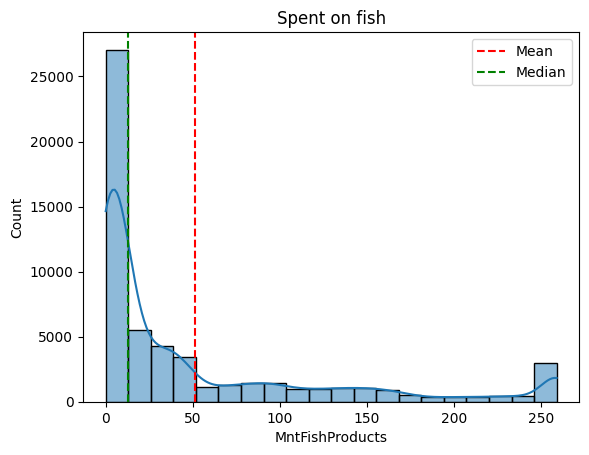

In [49]:
sns.histplot(clean_df['MntFishProducts'],bins=20, kde=True)
plt.axvline(clean_df['MntFishProducts'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['MntFishProducts'].median(), color='green', linestyle='--', label='Median')
plt.title('Spent on fish')
plt.legend()
plt.show()

### Amount on sweets

In [45]:
print(f"skewness: {clean_df['MntSweetProducts'].skew()}")
clean_df['MntSweetProducts'].describe()


skewness: 2.5917401987606232


count    55986.000000
mean        22.415497
std         41.552546
min          0.000000
25%          0.000000
50%          3.000000
75%         23.000000
max        263.000000
Name: MntSweetProducts, dtype: float64

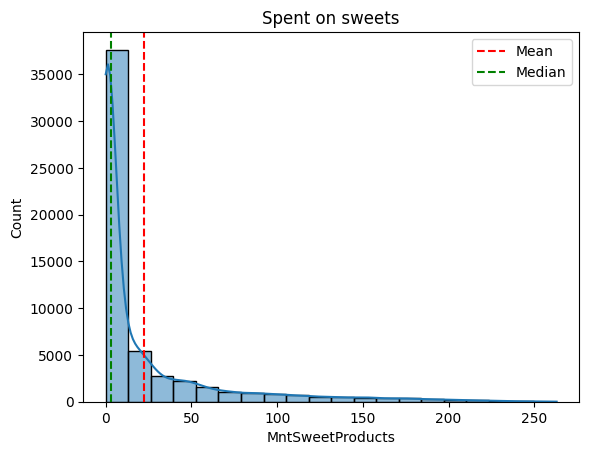

In [48]:
sns.histplot(clean_df['MntSweetProducts'],bins=20, kde=True)
plt.axvline(clean_df['MntSweetProducts'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['MntSweetProducts'].median(), color='green', linestyle='--', label='Median')
plt.title('Spent on sweets')
plt.legend()
plt.show()

### Amount on Gold

In [42]:
print(f"skewness: {clean_df['MntGoldProds'].skew()}")
clean_df['MntGoldProds'].describe()


skewness: 2.4567439056972473


count    55986.000000
mean        35.373933
std         50.615597
min          0.000000
25%          2.000000
50%         16.000000
75%         47.000000
max        359.000000
Name: MntGoldProds, dtype: float64

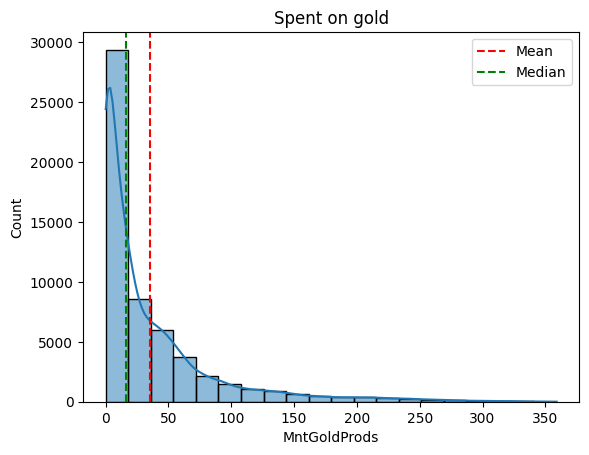

In [47]:
sns.histplot(clean_df['MntGoldProds'],bins=20, kde=True)
plt.axvline(clean_df['MntGoldProds'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['MntGoldProds'].median(), color='green', linestyle='--', label='Median')
plt.title('Spent on gold')
plt.legend()
plt.show()

## Family distribution

### Kids at home

In [31]:
(clean_df['Kidhome'].value_counts(normalize=True) * 100).round(2)

Kidhome
1    51.66
0    47.17
2     1.17
Name: proportion, dtype: float64

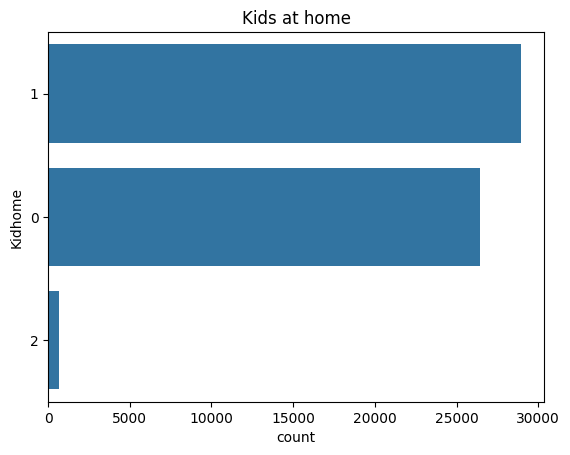

In [32]:
sns.countplot(y='Kidhome', data=clean_df, order=clean_df['Kidhome'].value_counts().index)
plt.title('Kids at home')
plt.show()

### Teen at home

In [33]:
(clean_df['Teenhome'].value_counts(normalize=True) * 100).round(2)

Teenhome
0    65.27
1    33.25
2     1.48
Name: proportion, dtype: float64

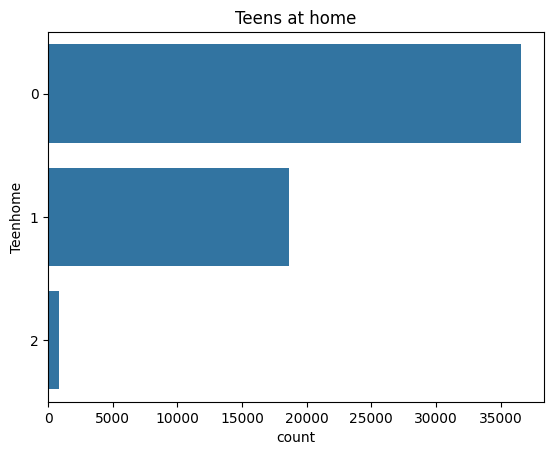

In [34]:
sns.countplot(y='Teenhome', data=clean_df, order=clean_df['Teenhome'].value_counts().index)
plt.title('Teens at home')
plt.show()

### Family Size Distribution

In [36]:
(clean_df['Family_Size'].value_counts(normalize=True) * 100).round(2)

Family_Size
2    35.87
3    35.77
1    15.14
4    12.70
5     0.51
6     0.00
Name: proportion, dtype: float64

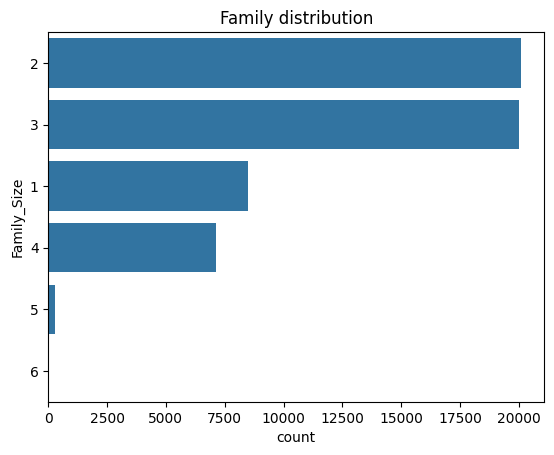

In [39]:
sns.countplot(y='Family_Size', data=clean_df, order=clean_df['Family_Size'].value_counts().index)
plt.title('Family distribution')
plt.show()

## Purchase Analysis

### Purchases made with a discount

In [59]:
print(f"skewness: {clean_df['NumDealsPurchases'].skew()}")
clean_df['NumDealsPurchases'].describe()

skewness: 1.5951325298763064


count    55986.000000
mean         2.171864
std          1.399692
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         15.000000
Name: NumDealsPurchases, dtype: float64

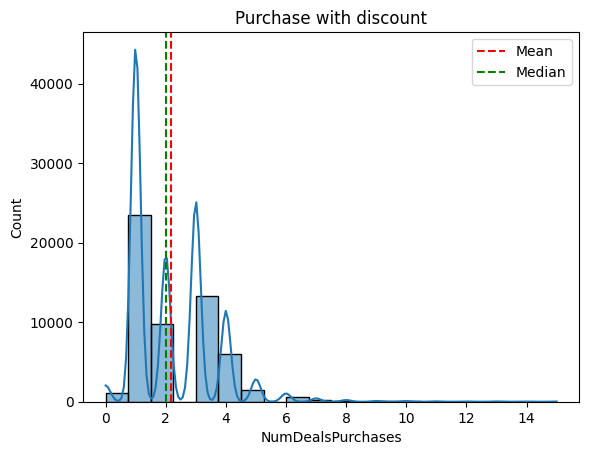

In [60]:
sns.histplot(clean_df['NumDealsPurchases'],bins=20, kde=True)
plt.axvline(clean_df['NumDealsPurchases'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['NumDealsPurchases'].median(), color='green', linestyle='--', label='Median')
plt.title('Purchase with discount')
plt.legend()
plt.show()

### Purchase through company website

In [67]:
print(f"skewness: {clean_df['NumWebPurchases'].skew()}")
clean_df['NumWebPurchases'].describe()

skewness: 1.1035573201968645


count    55986.000000
mean         4.248705
std          2.904460
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         15.000000
Name: NumWebPurchases, dtype: float64

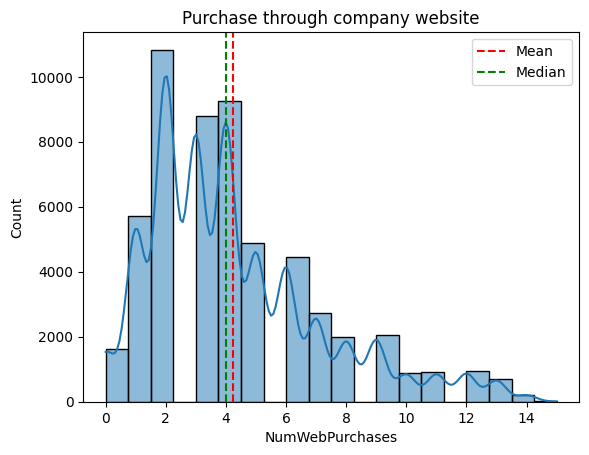

In [68]:
sns.histplot(clean_df['NumWebPurchases'],bins=20, kde=True)
plt.axvline(clean_df['NumWebPurchases'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['NumWebPurchases'].median(), color='green', linestyle='--', label='Median')
plt.title('Purchase through company website')
plt.legend()
plt.show()

### Purchase using catalogue

In [65]:
print(f"skewness: {clean_df['NumCatalogPurchases'].skew()}")
clean_df['NumCatalogPurchases'].describe()

skewness: 1.572741498430227


count    55986.000000
mean         2.110635
std          2.357511
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max         14.000000
Name: NumCatalogPurchases, dtype: float64

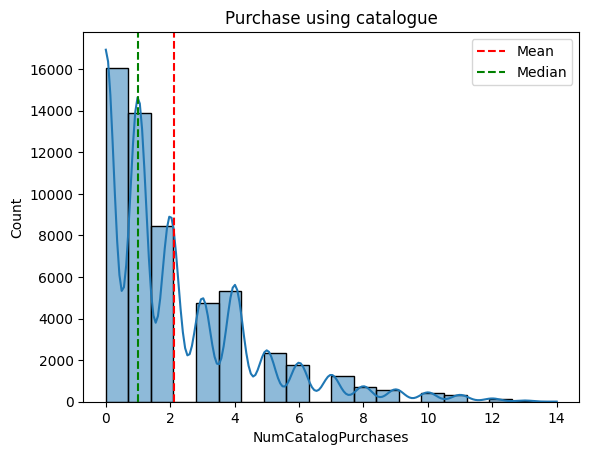

In [66]:
sns.histplot(clean_df['NumCatalogPurchases'],bins=20, kde=True)
plt.axvline(clean_df['NumCatalogPurchases'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['NumCatalogPurchases'].median(), color='green', linestyle='--', label='Median')
plt.title('Purchase using catalogue')
plt.legend()
plt.show()

### Purchage in stores

In [63]:
print(f"skewness: {clean_df['NumStorePurchases'].skew()}")
clean_df['NumStorePurchases'].describe()

skewness: 0.631337984468638


count    55986.000000
mean         4.706355
std          2.896508
min          0.000000
25%          3.000000
50%          4.000000
75%          6.000000
max         13.000000
Name: NumStorePurchases, dtype: float64

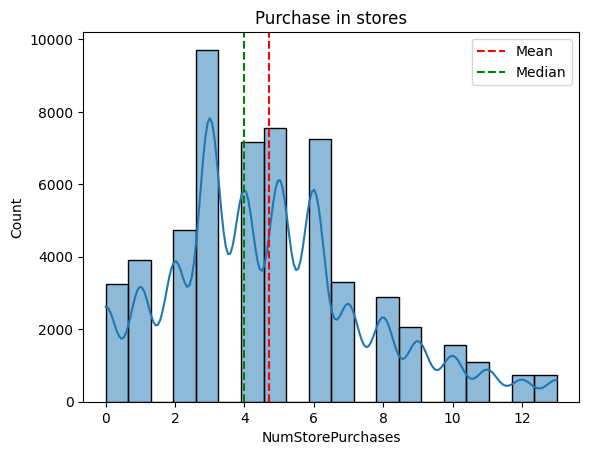

In [64]:
sns.histplot(clean_df['NumStorePurchases'],bins=20, kde=True)
plt.axvline(clean_df['NumStorePurchases'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['NumStorePurchases'].median(), color='green', linestyle='--', label='Median')
plt.title('Purchase in stores')
plt.legend()
plt.show()

### Visits to company websites

In [61]:
print(f"skewness: {clean_df['NumWebVisitsMonth'].skew()}")
clean_df['NumWebVisitsMonth'].describe()

skewness: -0.5961203122416247


count    55986.000000
mean         5.170346
std          2.555947
min          0.000000
25%          3.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: NumWebVisitsMonth, dtype: float64

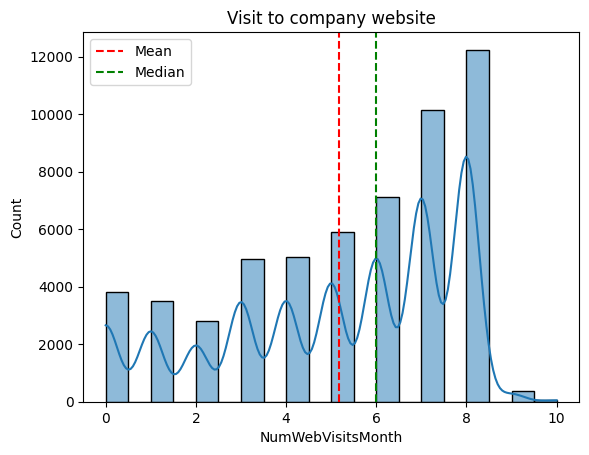

In [62]:
sns.histplot(clean_df['NumWebVisitsMonth'],bins=20, kde=True)
plt.axvline(clean_df['NumWebVisitsMonth'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['NumWebVisitsMonth'].median(), color='green', linestyle='--', label='Median')
plt.title('Visit to company website')
plt.legend()
plt.show()

### Total_Purchases

In [69]:
print(f"skewness: {clean_df['Total_Purchases'].skew()}")
clean_df['Total_Purchases'].describe()

skewness: 0.4792319371376106


count    55986.000000
mean        13.237559
std          5.680047
min          0.000000
25%          9.000000
50%         13.000000
75%         17.000000
max         46.000000
Name: Total_Purchases, dtype: float64

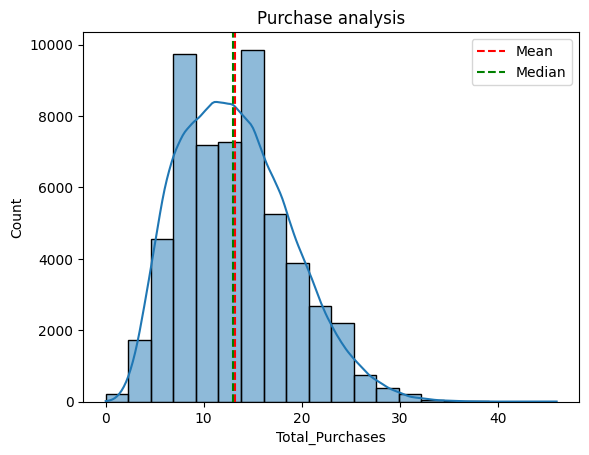

In [70]:
sns.histplot(clean_df['Total_Purchases'],bins=20, kde=True)
plt.axvline(clean_df['Total_Purchases'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['Total_Purchases'].median(), color='green', linestyle='--', label='Median')
plt.title('Purchase analysis')
plt.legend()
plt.show()

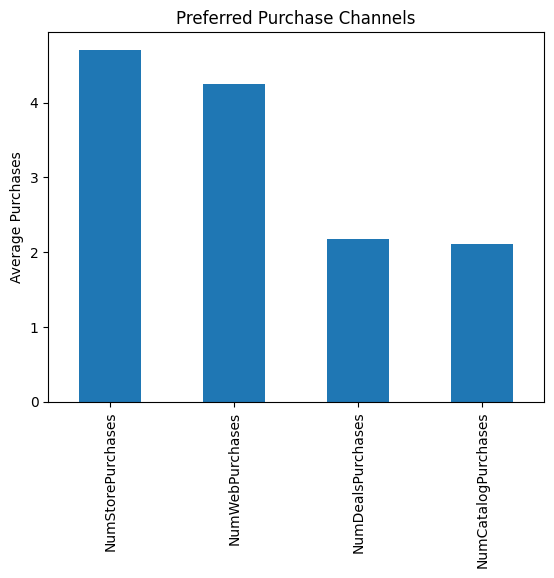

In [72]:
channels = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']

channel_means = clean_df[channels].mean().sort_values(ascending=False)
channel_means.plot(kind='bar')
plt.title("Preferred Purchase Channels")
plt.ylabel("Average Purchases")
plt.show()

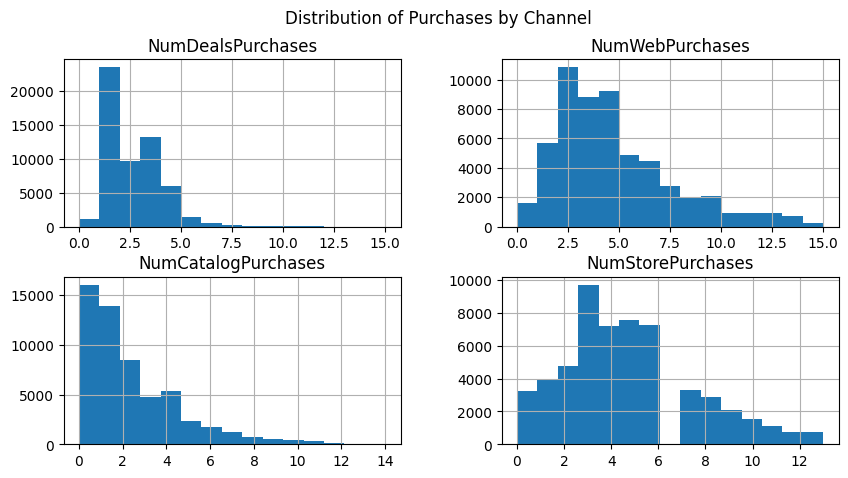

In [73]:
clean_df[channels].hist(bins=15, figsize=(10,5))
plt.suptitle("Distribution of Purchases by Channel")
plt.show()

## Recency Distribution

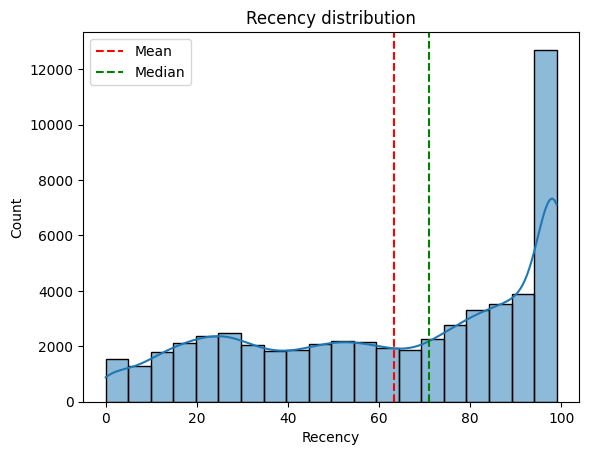

In [3]:
sns.histplot(clean_df['Recency'],bins=20, kde=True)
plt.axvline(clean_df['Recency'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(clean_df['Recency'].median(), color='green', linestyle='--', label='Median')
plt.title('Recency distribution')
plt.legend()
plt.show()

In [4]:
clean_df['Recency'].describe()

count    55986.000000
mean        63.222216
std         31.157121
min          0.000000
25%         35.000000
50%         71.000000
75%         93.000000
max         99.000000
Name: Recency, dtype: float64

In [5]:
clean_df['Recency'].skew()

np.float64(-0.42931125444332596)

In [11]:
bins = [0, 35, 71, 93, 100]
labels = ['Highly Active', 'Active', 'At Risk', 'Dormant']
clean_df['Recency_distri'] = pd.cut(clean_df['Recency'], bins=bins, labels=labels)

print(clean_df['Recency_distri'].value_counts().sort_index())
print('percentage:')
print((clean_df['Recency_distri'].value_counts(normalize=True) * 100).round(2))

Recency_distri
Highly Active    13220
Active           14377
At Risk          14123
Dormant          13451
Name: count, dtype: int64
percentage:
Recency_distri
Active           26.06
At Risk          25.60
Dormant          24.38
Highly Active    23.96
Name: proportion, dtype: float64
